In [1]:
import pandas as pd
import numpy as np
from scipy.signal import argrelextrema
from scipy.signal import find_peaks
from itertools import product
from tqdm import tqdm
import time
import numba as nb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import talib as ta
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
pd.set_option('display.float_format', '{:.7f}'.format)

In [3]:
df=pd.read_csv('../EUR_USD_2020_M5.csv')

In [4]:
df.set_index('time',inplace=True)

In [5]:
df['MACD_low'] = ta.MACD(df['l'], fastperiod=12, slowperiod=26, signalperiod=9)[2]

In [6]:
df['MACD_high'] = ta.MACD(df['h'], fastperiod=12, slowperiod=26, signalperiod=9)[2]

In [7]:
df['MACD']=ta.MACD(df['c'], fastperiod=12, slowperiod=26, signalperiod=9)[2]

In [8]:
df_test=df.iloc[:500].copy()

In [9]:
df_test

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD
time,,,,,,,,,
2020-01-01 22:00:00+00:00,1.1212400,1.1214600,1.1212400,1.1213200,9,True,NaN,NaN,NaN
2020-01-01 22:05:00+00:00,1.1213700,1.1213700,1.1212500,1.1212500,5,True,NaN,NaN,NaN
2020-01-01 22:10:00+00:00,1.1212900,1.1212900,1.1212500,1.1212500,2,True,NaN,NaN,NaN
2020-01-01 22:15:00+00:00,1.1213500,1.1215500,1.1213400,1.1214600,12,True,NaN,NaN,NaN
2020-01-01 22:20:00+00:00,1.1214300,1.1215400,1.1214300,1.1215400,4,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2020-01-03 15:35:00+00:00,1.1160500,1.1163300,1.1158200,1.1163300,86,True,0.0000734,0.0000603,0.0000755
2020-01-03 15:40:00+00:00,1.1163000,1.1165200,1.1162800,1.1163200,78,True,0.0000714,0.0000437,0.0000581
2020-01-03 15:45:00+00:00,1.1163000,1.1163000,1.1159200,1.1159600,88,True,0.0000390,0.0000121,0.0000166


In [10]:
df_test['idx']=range(len(df_test))

In [11]:
df

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD
time,,,,,,,,,
2020-01-01 22:00:00+00:00,1.1212400,1.1214600,1.1212400,1.1213200,9,True,NaN,NaN,NaN
2020-01-01 22:05:00+00:00,1.1213700,1.1213700,1.1212500,1.1212500,5,True,NaN,NaN,NaN
2020-01-01 22:10:00+00:00,1.1212900,1.1212900,1.1212500,1.1212500,2,True,NaN,NaN,NaN
2020-01-01 22:15:00+00:00,1.1213500,1.1215500,1.1213400,1.1214600,12,True,NaN,NaN,NaN
2020-01-01 22:20:00+00:00,1.1214300,1.1215400,1.1214300,1.1215400,4,True,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2020-12-31 21:35:00+00:00,1.2220100,1.2220700,1.2219600,1.2220600,35,True,0.0000768,0.0000651,0.0000658
2020-12-31 21:40:00+00:00,1.2220700,1.2220700,1.2218800,1.2219000,69,True,0.0000618,0.0000464,0.0000456
2020-12-31 21:45:00+00:00,1.2219200,1.2219600,1.2217400,1.2217400,72,True,0.0000403,0.0000255,0.0000205


In [12]:
def calc_low_points(low_vals):

    temp_min=low_vals[0]
    

    for i in range(len(low_vals)):

         if low_vals[i]<temp_min:

             temp_min=low_vals[i]


        

    if temp_min==low_vals[-2]:

       return low_vals[-2]

    else:

        return -101

In [13]:
def calc_high_points(high_vals):

    temp_max=high_vals[0]
    

    for i in range(len(high_vals)):

         if high_vals[i]>temp_max:

             temp_max=high_vals[i]


        

    if temp_max==high_vals[-2]:

       return high_vals[-2]

    else:

        return 101

In [14]:
def find_ll(rsi):


    temp_min=-101
   

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=-101:
       
            if rsi[i]<rsi[-1]:
    
                temp_min=rsi[i]
                
                break

               
    
    return temp_min

In [15]:
def find_hh(rsi):

    temp_max=101

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=101:
       
            if rsi[i]>rsi[-1]:
    
                temp_max=rsi[i]
                
                break

               
    
    return temp_max

In [16]:
def find_ll_idx(rsi):

    
    last_min_idx=0

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=-101:
        
            if rsi[i]<rsi[-1]:
    
                
                last_min_idx=i-1
                break

               
    
    return last_min_idx

In [17]:
def find_hh_idx(rsi):

    
    last_max_idx=0

    for i in range(len(rsi) - 2, -1, -1):
        if rsi[i]!=101:
        
            if rsi[i]>rsi[-1]:
        
                
                last_max_idx=i-1
                break

               
    
    return last_max_idx

In [19]:
window=30

In [42]:
df_test['ll']=df_test['MACD'].rolling(3).apply(calc_low_points, raw=True, engine='numba')

In [43]:
df_test['hh']=df_test['MACD'].rolling(3).apply(calc_high_points, raw=True, engine='numba')

In [44]:
df_test[50:100]

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-02 02:25:00+00:00,1.1220400,1.1221600,1.1220200,1.1221600,14,True,-0.0000321,-0.0000314,-0.0000250,50,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:30:00+00:00,1.1221400,1.1222200,1.1221400,1.1222200,8,True,-0.0000173,-0.0000213,-0.0000128,51,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:35:00+00:00,1.1222400,1.1223400,1.1222400,1.1223100,6,True,-0.0000014,-0.0000069,0.0000006,52,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:40:00+00:00,1.1223300,1.1223900,1.1223100,1.1223900,9,True,0.0000125,0.0000051,0.0000134,53,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:45:00+00:00,1.1224200,1.1224400,1.1224200,1.1224400,2,True,0.0000269,0.0000148,0.0000233,54,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:50:00+00:00,1.1224700,1.1224700,1.1224400,1.1224400,4,True,0.0000351,0.0000214,0.0000275,55,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:55:00+00:00,1.1224200,1.1224200,1.1222000,1.1222400,14,True,0.0000223,0.0000205,0.0000152,56,...,NaN,NaN,NaN,0.0000000,55.0000000,0.0000000,1.1224700,1.1212400,1.1214600,NaN
2020-01-02 03:00:00+00:00,1.1222200,1.1222700,1.1221900,1.1222700,11,True,0.0000117,0.0000085,0.0000077,57,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 03:05:00+00:00,1.1222900,1.1223200,1.1222900,1.1223000,7,True,0.0000099,0.0000029,0.0000037,58,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN


In [45]:
df_test['last_min']=df_test['ll'].rolling(window).apply(find_ll, raw=True, engine='numba')
df_test['last_max']=df_test['hh'].rolling(window).apply(find_hh, raw=True, engine='numba')

In [46]:
df_test[50:100]

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-02 02:25:00+00:00,1.1220400,1.1221600,1.1220200,1.1221600,14,True,-0.0000321,-0.0000314,-0.0000250,50,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:30:00+00:00,1.1221400,1.1222200,1.1221400,1.1222200,8,True,-0.0000173,-0.0000213,-0.0000128,51,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:35:00+00:00,1.1222400,1.1223400,1.1222400,1.1223100,6,True,-0.0000014,-0.0000069,0.0000006,52,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:40:00+00:00,1.1223300,1.1223900,1.1223100,1.1223900,9,True,0.0000125,0.0000051,0.0000134,53,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:45:00+00:00,1.1224200,1.1224400,1.1224200,1.1224400,2,True,0.0000269,0.0000148,0.0000233,54,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:50:00+00:00,1.1224700,1.1224700,1.1224400,1.1224400,4,True,0.0000351,0.0000214,0.0000275,55,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:55:00+00:00,1.1224200,1.1224200,1.1222000,1.1222400,14,True,0.0000223,0.0000205,0.0000152,56,...,NaN,NaN,NaN,0.0000000,55.0000000,0.0000000,1.1224700,1.1212400,1.1214600,NaN
2020-01-02 03:00:00+00:00,1.1222200,1.1222700,1.1221900,1.1222700,11,True,0.0000117,0.0000085,0.0000077,57,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 03:05:00+00:00,1.1222900,1.1223200,1.1222900,1.1223000,7,True,0.0000099,0.0000029,0.0000037,58,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN


In [47]:
df_test['prev_min_idx']=df_test['ll'].rolling(window).apply(find_ll_idx, raw=True, engine='numba')+df_test.idx-window+1
df_test['prev_max_idx']=df_test['hh'].rolling(window).apply(find_hh_idx, raw=True, engine='numba')+df_test.idx-window+1

In [48]:
df_test[50:100]

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-02 02:25:00+00:00,1.1220400,1.1221600,1.1220200,1.1221600,14,True,-0.0000321,-0.0000314,-0.0000250,50,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:30:00+00:00,1.1221400,1.1222200,1.1221400,1.1222200,8,True,-0.0000173,-0.0000213,-0.0000128,51,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:35:00+00:00,1.1222400,1.1223400,1.1222400,1.1223100,6,True,-0.0000014,-0.0000069,0.0000006,52,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:40:00+00:00,1.1223300,1.1223900,1.1223100,1.1223900,9,True,0.0000125,0.0000051,0.0000134,53,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:45:00+00:00,1.1224200,1.1224400,1.1224200,1.1224400,2,True,0.0000269,0.0000148,0.0000233,54,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:50:00+00:00,1.1224700,1.1224700,1.1224400,1.1224400,4,True,0.0000351,0.0000214,0.0000275,55,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:55:00+00:00,1.1224200,1.1224200,1.1222000,1.1222400,14,True,0.0000223,0.0000205,0.0000152,56,...,NaN,NaN,NaN,0.0000000,55.0000000,0.0000000,1.1224700,1.1212400,1.1214600,NaN
2020-01-02 03:00:00+00:00,1.1222200,1.1222700,1.1221900,1.1222700,11,True,0.0000117,0.0000085,0.0000077,57,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 03:05:00+00:00,1.1222900,1.1223200,1.1222900,1.1223000,7,True,0.0000099,0.0000029,0.0000037,58,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN


In [49]:
df_test['last_min_idx']=np.where((df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['ll'].notna()), df_test['idx'].shift(),0)
df_test['last_max_idx']=np.where((df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['hh'].notna()), df_test['idx'].shift(),0)

In [50]:
df_test[50:100]

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-02 02:25:00+00:00,1.1220400,1.1221600,1.1220200,1.1221600,14,True,-0.0000321,-0.0000314,-0.0000250,50,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:30:00+00:00,1.1221400,1.1222200,1.1221400,1.1222200,8,True,-0.0000173,-0.0000213,-0.0000128,51,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:35:00+00:00,1.1222400,1.1223400,1.1222400,1.1223100,6,True,-0.0000014,-0.0000069,0.0000006,52,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:40:00+00:00,1.1223300,1.1223900,1.1223100,1.1223900,9,True,0.0000125,0.0000051,0.0000134,53,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:45:00+00:00,1.1224200,1.1224400,1.1224200,1.1224400,2,True,0.0000269,0.0000148,0.0000233,54,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:50:00+00:00,1.1224700,1.1224700,1.1224400,1.1224400,4,True,0.0000351,0.0000214,0.0000275,55,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:55:00+00:00,1.1224200,1.1224200,1.1222000,1.1222400,14,True,0.0000223,0.0000205,0.0000152,56,...,NaN,NaN,NaN,0.0000000,55.0000000,0.0000000,1.1224700,1.1212400,1.1214600,NaN
2020-01-02 03:00:00+00:00,1.1222200,1.1222700,1.1221900,1.1222700,11,True,0.0000117,0.0000085,0.0000077,57,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 03:05:00+00:00,1.1222900,1.1223200,1.1222900,1.1223000,7,True,0.0000099,0.0000029,0.0000037,58,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN


In [51]:
df_test['last_min_price']=np.where((df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['ll'].notna()), df_test['l'].shift(),0)
df_test['last_max_price']=np.where((df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['hh'].notna()), df_test['h'].shift(),0)

In [52]:
df_test[50:100]

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-02 02:25:00+00:00,1.1220400,1.1221600,1.1220200,1.1221600,14,True,-0.0000321,-0.0000314,-0.0000250,50,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:30:00+00:00,1.1221400,1.1222200,1.1221400,1.1222200,8,True,-0.0000173,-0.0000213,-0.0000128,51,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:35:00+00:00,1.1222400,1.1223400,1.1222400,1.1223100,6,True,-0.0000014,-0.0000069,0.0000006,52,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:40:00+00:00,1.1223300,1.1223900,1.1223100,1.1223900,9,True,0.0000125,0.0000051,0.0000134,53,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:45:00+00:00,1.1224200,1.1224400,1.1224200,1.1224400,2,True,0.0000269,0.0000148,0.0000233,54,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:50:00+00:00,1.1224700,1.1224700,1.1224400,1.1224400,4,True,0.0000351,0.0000214,0.0000275,55,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 02:55:00+00:00,1.1224200,1.1224200,1.1222000,1.1222400,14,True,0.0000223,0.0000205,0.0000152,56,...,NaN,NaN,NaN,0.0000000,55.0000000,0.0000000,1.1224700,1.1212400,1.1214600,NaN
2020-01-02 03:00:00+00:00,1.1222200,1.1222700,1.1221900,1.1222700,11,True,0.0000117,0.0000085,0.0000077,57,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-02 03:05:00+00:00,1.1222900,1.1223200,1.1222900,1.1223000,7,True,0.0000099,0.0000029,0.0000037,58,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN


In [53]:
prev_min_prices_idx=np.array(df_test['prev_min_idx'])
prev_max_prices_idx=np.array(df_test['prev_max_idx'])
prev_min_prices=np.array(df_test['l'].iloc[np.nan_to_num(prev_min_prices_idx)])
prev_max_prices=np.array(df_test['h'].iloc[np.nan_to_num(prev_max_prices_idx)])
df_test['prev_min_prices']=prev_min_prices
df_test['prev_max_prices']=prev_max_prices

In [54]:
df_test[50:100].loc[:,['idx','h','MACD_high','hh','last_max','last_max_idx','prev_max_idx','last_max_price','prev_max_prices']]

,idx,h,MACD_high,hh,last_max,last_max_idx,prev_max_idx,last_max_price,prev_max_prices
time,,,,,,,,,
2020-01-02 02:25:00+00:00,50,1.1221600,-0.0000314,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:30:00+00:00,51,1.1222200,-0.0000213,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:35:00+00:00,52,1.1223400,-0.0000069,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:40:00+00:00,53,1.1223900,0.0000051,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:45:00+00:00,54,1.1224400,0.0000148,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:50:00+00:00,55,1.1224700,0.0000214,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 02:55:00+00:00,56,1.1224200,0.0000205,0.0000275,NaN,55.0000000,NaN,1.1224700,1.1214600
2020-01-02 03:00:00+00:00,57,1.1222700,0.0000085,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600
2020-01-02 03:05:00+00:00,58,1.1223200,0.0000029,101.0000000,NaN,0.0000000,NaN,0.0000000,1.1214600


In [55]:
df_test[50:100].loc[:,['idx','l','MACD_low','ll','last_min','last_min_idx','prev_min_idx','last_min_price','prev_min_prices']]

,idx,l,MACD_low,ll,last_min,last_min_idx,prev_min_idx,last_min_price,prev_min_prices
time,,,,,,,,,
2020-01-02 02:25:00+00:00,50,1.1220200,-0.0000321,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:30:00+00:00,51,1.1221400,-0.0000173,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:35:00+00:00,52,1.1222400,-0.0000014,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:40:00+00:00,53,1.1223100,0.0000125,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:45:00+00:00,54,1.1224200,0.0000269,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:50:00+00:00,55,1.1224400,0.0000351,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 02:55:00+00:00,56,1.1222000,0.0000223,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 03:00:00+00:00,57,1.1221900,0.0000117,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400
2020-01-02 03:05:00+00:00,58,1.1222900,0.0000099,-101.0000000,NaN,0.0000000,NaN,0.0000000,1.1212400


In [56]:
cond_buy_check=(df_test['ll']!=-101)&(df_test['last_min']!=-101)&(df_test['prev_min_idx'].notna())
cond_buy_price=(df_test['last_min_price']!=0)&(df_test['prev_min_prices']>df_test['last_min_price'])
cond_sell_check=(df_test['hh']!=101)&(df_test['last_max']!=101)&(df_test['prev_max_idx'].notna())
cond_sell_price=(df_test['last_max_price']!=0)&(df_test['prev_max_prices']<df_test['last_max_price'])

In [57]:
df_test['div_pos']=np.nan
df_test['div_pos']=np.where(cond_buy_check&cond_buy_price,1,df_test['div_pos'])
df_test['div_pos']=np.where(cond_sell_check&cond_sell_price,-1,df_test['div_pos'])


In [58]:
df_test['div_pos'].value_counts()

div_pos
-1.0000000    12
1.0000000     12
Name: count, dtype: int64

In [59]:
df_test

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 22:00:00+00:00,1.1212400,1.1214600,1.1212400,1.1213200,9,True,NaN,NaN,NaN,0,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:05:00+00:00,1.1213700,1.1213700,1.1212500,1.1212500,5,True,NaN,NaN,NaN,1,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:10:00+00:00,1.1212900,1.1212900,1.1212500,1.1212500,2,True,NaN,NaN,NaN,2,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:15:00+00:00,1.1213500,1.1215500,1.1213400,1.1214600,12,True,NaN,NaN,NaN,3,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:20:00+00:00,1.1214300,1.1215400,1.1214300,1.1215400,4,True,NaN,NaN,NaN,4,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-03 15:35:00+00:00,1.1160500,1.1163300,1.1158200,1.1163300,86,True,0.0000734,0.0000603,0.0000755,495,...,101.0000000,466.0000000,466.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1143600,1.1147600,NaN
2020-01-03 15:40:00+00:00,1.1163000,1.1165200,1.1162800,1.1163200,78,True,0.0000714,0.0000437,0.0000581,496,...,101.0000000,467.0000000,467.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1145600,1.1147500,NaN
2020-01-03 15:45:00+00:00,1.1163000,1.1163000,1.1159200,1.1159600,88,True,0.0000390,0.0000121,0.0000166,497,...,101.0000000,468.0000000,468.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1145400,1.1148800,NaN


In [60]:
df_plot=df_test.copy()

In [61]:
df_plot

,o,h,l,c,volume,complete,MACD_low,MACD_high,MACD,idx,...,last_max,prev_min_idx,prev_max_idx,last_min_idx,last_max_idx,last_min_price,last_max_price,prev_min_prices,prev_max_prices,div_pos
time,,,,,,,,,,,,,,,,,,,,,
2020-01-01 22:00:00+00:00,1.1212400,1.1214600,1.1212400,1.1213200,9,True,NaN,NaN,NaN,0,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:05:00+00:00,1.1213700,1.1213700,1.1212500,1.1212500,5,True,NaN,NaN,NaN,1,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:10:00+00:00,1.1212900,1.1212900,1.1212500,1.1212500,2,True,NaN,NaN,NaN,2,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:15:00+00:00,1.1213500,1.1215500,1.1213400,1.1214600,12,True,NaN,NaN,NaN,3,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
2020-01-01 22:20:00+00:00,1.1214300,1.1215400,1.1214300,1.1215400,4,True,NaN,NaN,NaN,4,...,NaN,NaN,NaN,0.0000000,0.0000000,0.0000000,0.0000000,1.1212400,1.1214600,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-03 15:35:00+00:00,1.1160500,1.1163300,1.1158200,1.1163300,86,True,0.0000734,0.0000603,0.0000755,495,...,101.0000000,466.0000000,466.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1143600,1.1147600,NaN
2020-01-03 15:40:00+00:00,1.1163000,1.1165200,1.1162800,1.1163200,78,True,0.0000714,0.0000437,0.0000581,496,...,101.0000000,467.0000000,467.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1145600,1.1147500,NaN
2020-01-03 15:45:00+00:00,1.1163000,1.1163000,1.1159200,1.1159600,88,True,0.0000390,0.0000121,0.0000166,497,...,101.0000000,468.0000000,468.0000000,0.0000000,0.0000000,0.0000000,0.0000000,1.1145400,1.1148800,NaN


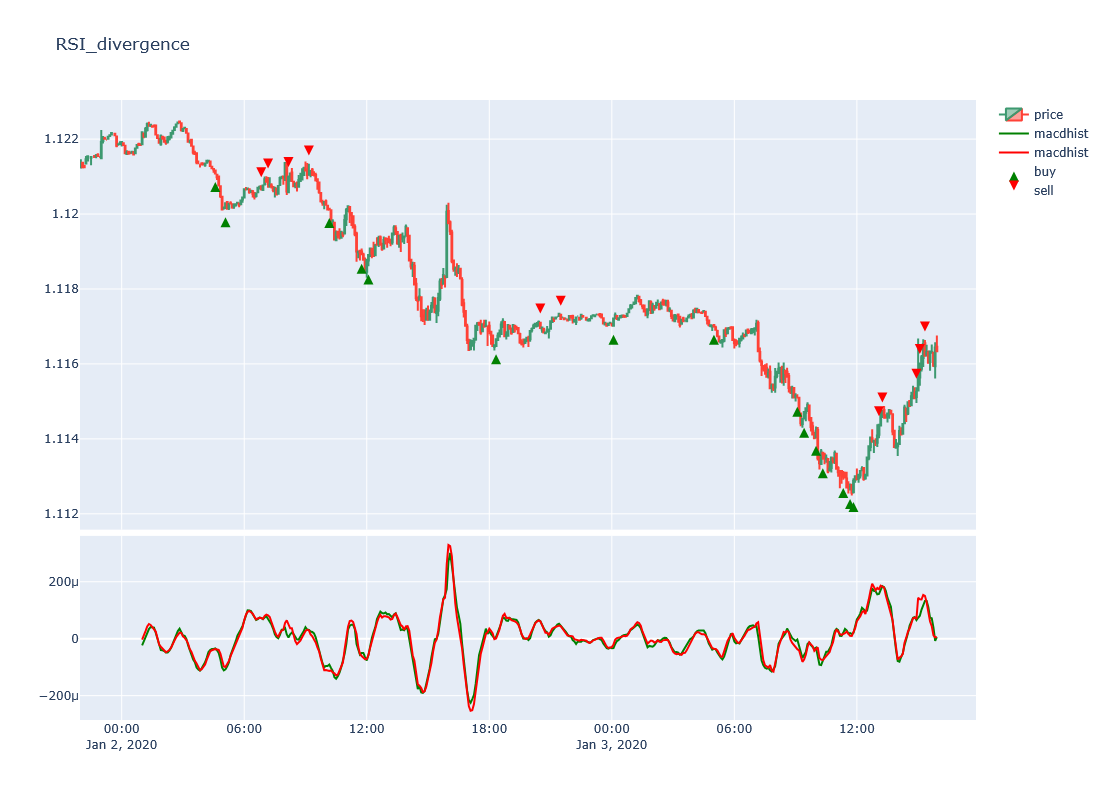

In [118]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='RSI_divergence')

pos_col='div_pos'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD_low'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()

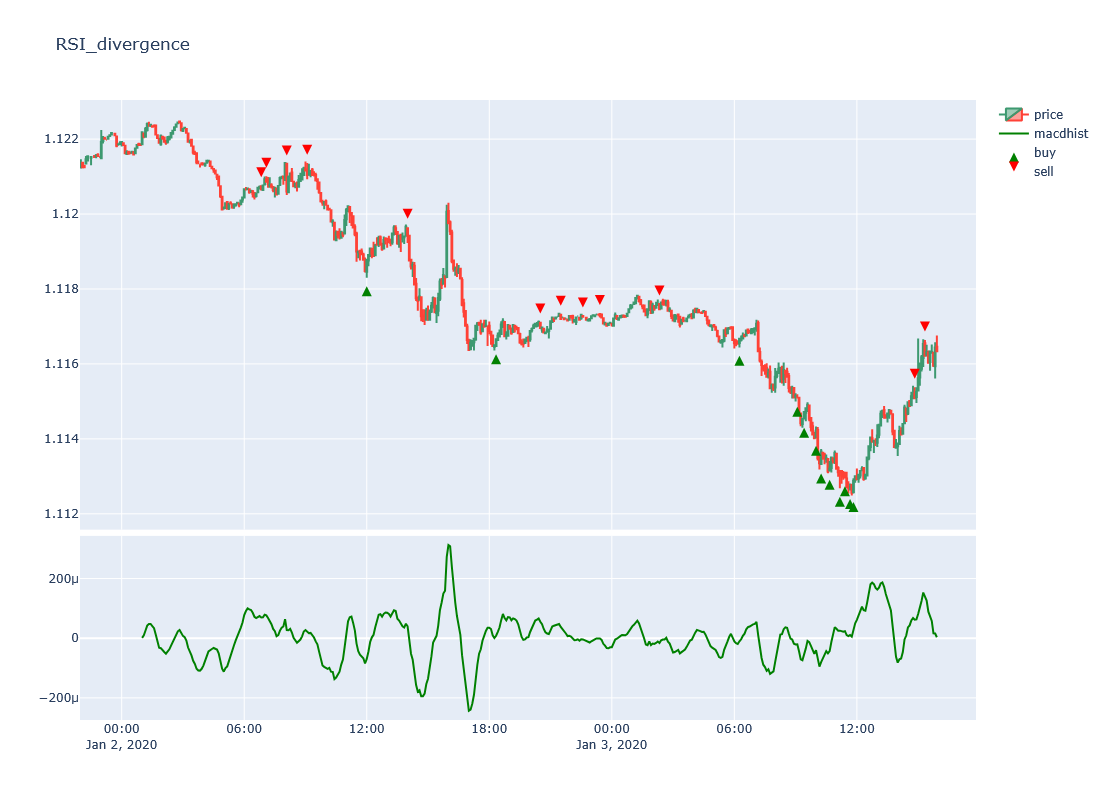

In [62]:
figure = make_subplots(rows=2, cols=1, row_heights=[0.7,0.3], shared_xaxes=True,vertical_spacing=0.01)
figure.update_layout(height=800, width=1200, title_text='RSI_divergence')

pos_col='div_pos'

y_color_buy=df_plot[df_plot[pos_col]==1]['l']*0.9998
y_color_buy_index=df_plot[df_plot[pos_col]==1].index
y_color_sell=df_plot[df_plot[pos_col]==-1]['h']*1.0002
y_color_sell_index=df_plot[df_plot[pos_col]==-1].index

#y_color_sell=df_plot[df_plot['pos_ch_bear']==-1]['h']*1.0002
#y_color_sell_index=df_plot[df_plot['pos_ch_bear']==-1].index
#y_color_buy=df_plot[df_plot['pos_ch_bull']==1]['l']*0.9998
#y_color_buy_index=df_plot[df_plot['pos_ch_bull']==1].index


figure.add_trace(go.Candlestick(x=df_plot.index,
                                open=df_plot['o'],
                                high=df_plot['h'],
                                low=df_plot['l'],
                                close=df_plot['c'],
                                name='price'), row=1, col=1)

figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD'],mode='lines',line_color='green',name='macdhist'),col=1,row=2)
#figure.add_trace(go.Scatter(x=df_plot.index,y=df_plot['MACD_high'],mode='lines',line_color='red',name='macdhist'),col=1,row=2)
figure.add_trace(go.Scatter(x=y_color_buy_index, y=y_color_buy, mode='markers', marker_symbol='arrow-up', marker_color='green', name='buy', marker_size=10), col=1, row=1)
figure.add_trace(go.Scatter(x=y_color_sell_index, y=y_color_sell, mode='markers', marker_symbol='arrow-down', marker_color='red', name='sell', marker_size=10), col=1, row=1)
#for i in idxs:
    

    #figure.add_trace(go.Scatter(x=df_plot.loc[i].index,y=df_plot['RSI_low'].loc[i],mode='lines',line_color='red',name='macdhist'),col=1,row=2)

    

figure.update_layout(xaxis_rangeslider_visible=False)
figure.update_xaxes(
        rangebreaks=[
            dict(bounds=["sat", "mon"])]
    )
figure.show()